# classify.ipynb

objective: classify fish species from image

In [79]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [80]:
with open('../data/folds-w-meta.pkl', 'rb') as f:
    metadata = pickle.load(f, encoding='latin1')

C:\Users\matth\AppData\Local\Temp\ipykernel_10848\637881968.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  metadata = pickle.load(f, encoding='latin1')


In [81]:
data = metadata[0]['data']


print(type(data)) # we have a 5D tensor
# 63 samples of fish, 9 views/images per fish, height 75px, width 200px, 3 RGB color channels
print(data.shape)
print(data.ndim)
print(data.dtype)

print(f'num of folds:{len(metadata)}')

<class 'numpy.ndarray'>
(63, 9, 75, 200, 3)
5
uint8
num of folds:10


In [82]:
# looking at all the folds

for i in range(len(metadata)):
    print(f"Fold {i}")
    print(metadata[i]['data'].shape)

Fold 0
(63, 9, 75, 200, 3)
Fold 1
(63, 9, 75, 200, 3)
Fold 2
(63, 9, 75, 200, 3)
Fold 3
(62, 9, 75, 200, 3)
Fold 4
(62, 9, 75, 200, 3)
Fold 5
(62, 9, 75, 200, 3)
Fold 6
(62, 9, 75, 200, 3)
Fold 7
(62, 9, 75, 200, 3)
Fold 8
(62, 9, 75, 200, 3)
Fold 9
(62, 9, 75, 200, 3)


In [83]:
train_folds = list(range(0, 8)) # using folds 0-7 to train 
val_fold = 8 # using fold 8 to validate
test_fold = 9 # using fold 9 to test

def load_folds(fold_indices, label_key='class'):
    X_list = []
    y_list = []

    for i in fold_indices:
        X = metadata[i]['data']          # (N, 9, 75, 200, 3)
        y = metadata[i][label_key]       # (N,)

        X = X.reshape(-1, 75, 200, 3)    # (N*9, 75, 200, 3)
        y = np.repeat(y, 9)              # (N*9,)

        X_list.append(X)
        y_list.append(y)

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)

    return X_all, y_all

X_train, y_train = load_folds(train_folds, label_key='class')
X_val, y_val = load_folds([val_fold], label_key='class')
X_test, y_test = load_folds([test_fold], label_key='class')

print(X_train.shape, y_train.shape) # 4491 train images
print(X_val.shape, y_val.shape)  # 558 val images
print(X_test.shape, y_test.shape) # 558 test images

# remember 75 x 200 px size of the image, being 3 channel rgb

(4491, 75, 200, 3) (4491,)
(558, 75, 200, 3) (558,)
(558, 75, 200, 3) (558,)


In [84]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [85]:
# normalization step
X_train = X_train.astype("float32") / 255.0
X_val   = X_val.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

print(X_train.min(), X_train.max())

0.0 1.0


In [86]:
le = LabelEncoder()

all_labels = np.concatenate([y_train, y_val, y_test])
le.fit(all_labels)

y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)

print(le.classes_)
print(num_classes)

['BHC' 'BUF' 'CC' 'CCF' 'CWS' 'FWD' 'GC' 'GF' 'GS' 'LNG' 'LNS' 'NHS' 'NP'
 'QBS' 'RHS' 'RRS' 'SC' 'SL' 'SMB' 'WB' 'WP' 'WYE']
22


In [87]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # match channel size if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [88]:
inputs = layers.Input(shape=(75, 200, 3))

x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 32)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 64)
x = layers.MaxPooling2D()(x)

x = residual_block(x, 128)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [89]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 75, 200,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 75, 200,   │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 200,   │        128 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 37, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 37, 100,   │      9,248 │ max_pooling2d_9[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 37, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 37, 100,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 37, 100,   │          0 │ add_9[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 18, 50,    │          0 │ activation_9[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 18, 50,    │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_30[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 18, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_31[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 18, 50,    │      2,112 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 18, 50,    │          0 │ batch_normalizat

 Total params: 318,294 (1.21 MB)

 Trainable params: 317,334 (1.21 MB)

 Non-trainable params: 960 (3.75 KB)

In [90]:
history = model.fit(
    X_train,
    y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=10,
    batch_size=32
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.5778 - loss: 1.4455 - val_accuracy: 0.2742 - val_loss: 3.0965
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.7769 - loss: 0.7811 - val_accuracy: 0.2885 - val_loss: 3.3837
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.8359 - loss: 0.5814 - val_accuracy: 0.3566 - val_loss: 2.1839
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.8682 - loss: 0.4522 - val_accuracy: 0.4498 - val_loss: 2.8954
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.8831 - loss: 0.3956 - val_accuracy: 0.6989 - val_loss: 1.2446
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.8960 - loss: 0.3449 - val_accuracy: 0.5412 - val_loss: 2.8880
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.9087 - loss: 0.3091 - val_accuracy: 0.2007 - val_loss: 10.7160
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9147 - loss: 0.2683 -

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_enc)

print("Test accuracy:", test_acc) # random guess expected value is like 4.5%

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2760 - loss: 5.4360
Test accuracy: 0.2759856581687927


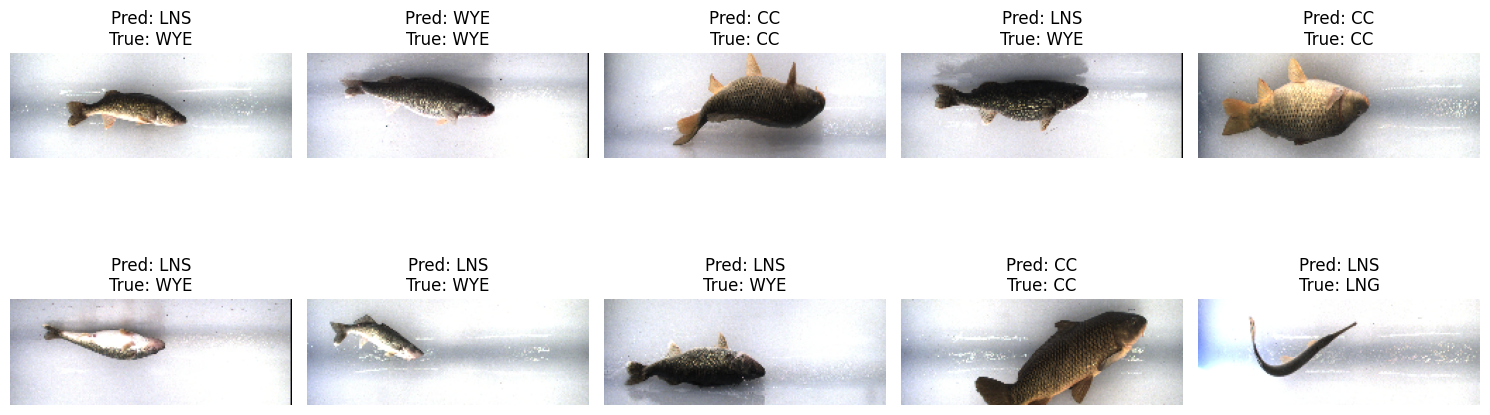

In [98]:
# pick 10 random image indices
random_idxs = np.random.choice(len(X_test), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, idx in zip(axes.flat, random_idxs):

    ax.imshow(X_test[idx])
    ax.set_title(f"Pred: {pred_labels[idx]}\nTrue: {y_test[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()